# Prediksi Gaji Profesional IT Menggunakan Linear Regression

## Abstrak

Penelitian ini menganalisis dataset gaji profesional IT untuk memprediksi besaran gaji berdasarkan jabatan, tingkat pengalaman, jenis pekerjaan, ukuran perusahaan, dan rasio kerja jarak jauh menggunakan metode **Linear Regression**. Hasil analisis menunjukkan bahwa kategori profesi **Manager/Leadership** memiliki rata-rata gaji tertinggi di antara semua kategori jabatan yang diteliti. Secara keseluruhan, urutan profesi dari gaji tertinggi hingga terendah adalah: **Manager/Leadership → ML/AI Specialist → Data Scientist → Engineer → Analyst → Lainnya**. Detail persentase kontribusi dan perbandingan antar profesi disajikan secara lengkap pada bagian hasil analisis di bawah.

**Dataset:** salaries.csv — informasi gaji profesional IT  
**Metode:** Linear Regression (scikit-learn)


## 1. Import Library

In [1]:
# Manipulasi data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')
sns.set_palette('husl')

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Memuat Dataset

In [2]:
# Memuat dataset
df = pd.read_csv('salaries.csv')

# Menampilkan informasi dasar
print(f'Bentuk dataset: {df.shape}')
print(f'\nKolom: {list(df.columns)}')
print(f'\nBeberapa baris pertama:')
df.head()

Bentuk dataset: (151445, 11)

Kolom: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Beberapa baris pertama:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


In [3]:
# Tipe data dan informasi
print('Informasi Dataset:')
df.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           151445 non-null  int64 
 1   experience_level    151445 non-null  object
 2   employment_type     151445 non-null  object
 3   job_title           151445 non-null  object
 4   salary              151445 non-null  int64 
 5   salary_currency     151445 non-null  object
 6   salary_in_usd       151445 non-null  int64 
 7   employee_residence  151445 non-null  object
 8   remote_ratio        151445 non-null  int64 
 9   company_location    151445 non-null  object
 10  company_size        151445 non-null  object
dtypes: int64(4), object(7)
memory usage: 12.7+ MB


## 3. Analisis Data Eksploratif (EDA)

Menganalisis data untuk memahami pola dan mengidentifikasi fitur yang berkorelasi dengan gaji.

In [4]:
# Memeriksa nilai yang hilang
print('Nilai yang Hilang:')
print(df.isnull().sum())
print(f'\nTotal nilai hilang: {df.isnull().sum().sum()}')

Nilai yang Hilang:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Total nilai hilang: 0


In [5]:
# Ringkasan statistik
print('Ringkasan Statistik:')
df.describe()

Ringkasan Statistik:


,work_year,salary,salary_in_usd,remote_ratio
count,151445.000000,1.514450e+05,151445.000000,151445.000000
mean,2024.435313,1.628380e+05,157527.458411,20.938625
std,0.671842,2.080124e+05,74150.772377,40.620393
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060000e+05,105800.000000,0.000000
50%,2025.000000,1.470000e+05,146100.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


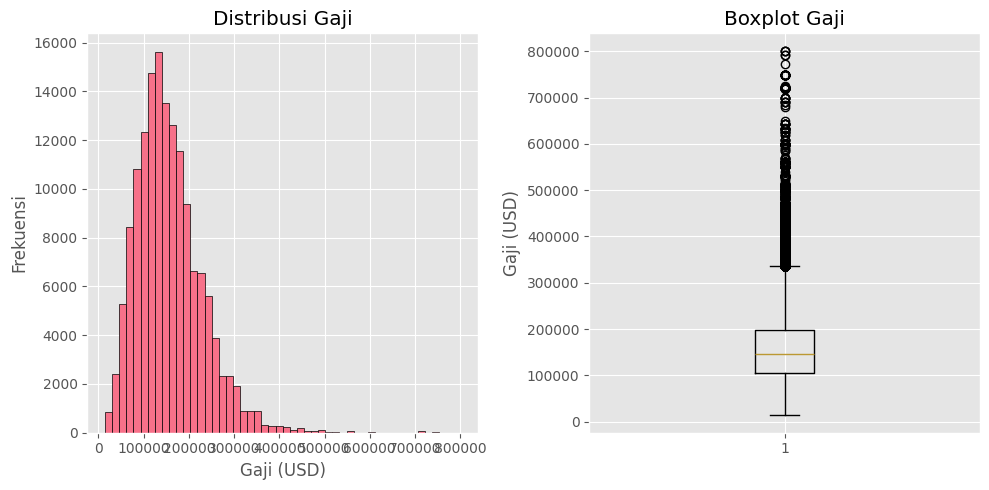

Statistik Gaji:
Rata-rata: $157,527.46
Median: $146,100.00
Min: $15,000.00
Maks: $800,000.00


In [6]:
# Distribusi gaji
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df['salary_in_usd'], bins=50, edgecolor='black')
plt.xlabel('Gaji (USD)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Gaji')

plt.subplot(1, 2, 2)
plt.boxplot(df['salary_in_usd'])
plt.ylabel('Gaji (USD)')
plt.title('Boxplot Gaji')

plt.tight_layout()
plt.show()

print(f'Statistik Gaji:')
print(f'Rata-rata: ${df["salary_in_usd"].mean():,.2f}')
print(f'Median: ${df["salary_in_usd"].median():,.2f}')
print(f'Min: ${df["salary_in_usd"].min():,.2f}')
print(f'Maks: ${df["salary_in_usd"].max():,.2f}')

<Figure size 1000x600 with 0 Axes>

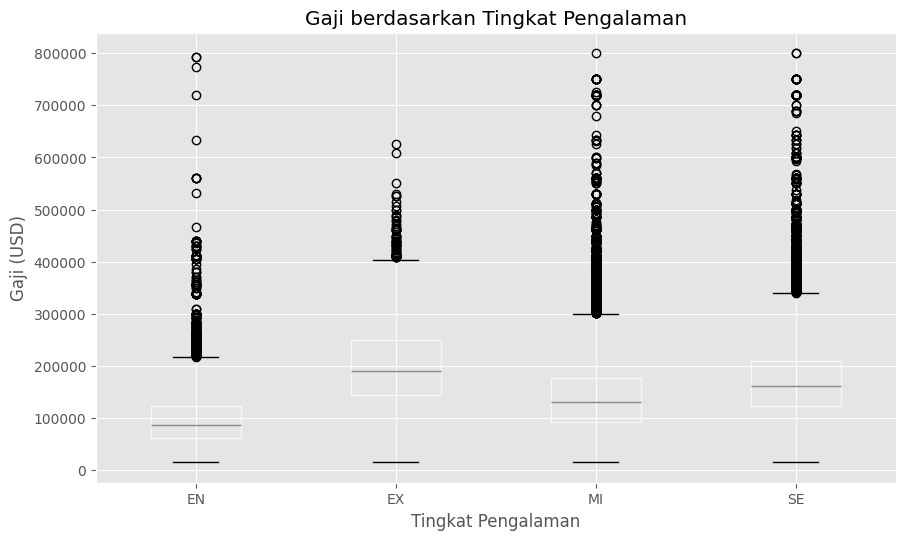


Rata-rata Gaji berdasarkan Tingkat Pengalaman:
experience_level
EX    200471.428537
SE    172657.764364
MI    142301.177831
EN     98961.735270
Name: salary_in_usd, dtype: float64


In [7]:
# Tingkat pengalaman vs Gaji - menunjukkan korelasi
plt.figure(figsize=(10, 6))
df.boxplot(column='salary_in_usd', by='experience_level', figsize=(10, 6))
plt.xlabel('Tingkat Pengalaman')
plt.ylabel('Gaji (USD)')
plt.title('Gaji berdasarkan Tingkat Pengalaman')
plt.suptitle('')
plt.show()

print('\nRata-rata Gaji berdasarkan Tingkat Pengalaman:')
print(df.groupby('experience_level')['salary_in_usd'].mean().sort_values(ascending=False))

<Figure size 1000x600 with 0 Axes>

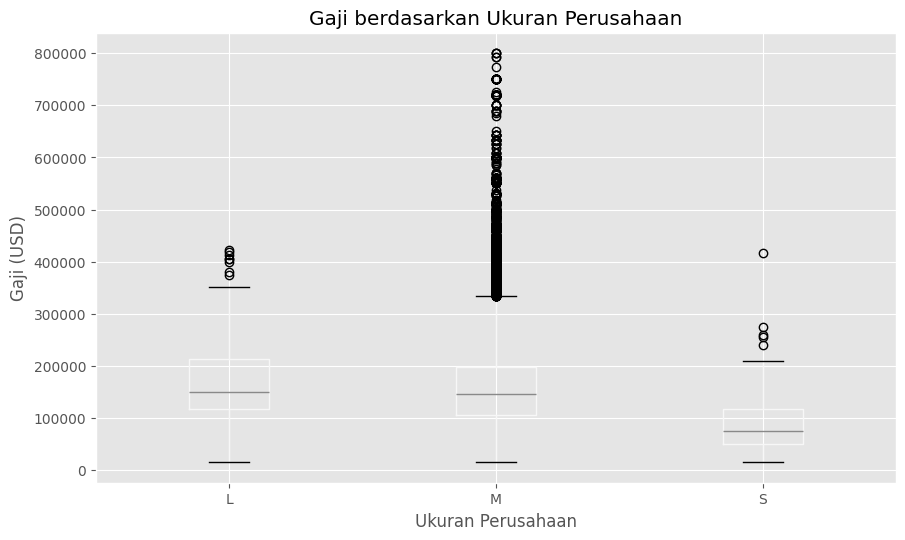


Rata-rata Gaji berdasarkan Ukuran Perusahaan:
company_size
L    159339.729496
M    157581.824483
S     87835.258065
Name: salary_in_usd, dtype: float64


In [8]:
# Ukuran perusahaan vs Gaji
plt.figure(figsize=(10, 6))
df.boxplot(column='salary_in_usd', by='company_size', figsize=(10, 6))
plt.xlabel('Ukuran Perusahaan')
plt.ylabel('Gaji (USD)')
plt.title('Gaji berdasarkan Ukuran Perusahaan')
plt.suptitle('')
plt.show()

print('\nRata-rata Gaji berdasarkan Ukuran Perusahaan:')
print(df.groupby('company_size')['salary_in_usd'].mean().sort_values(ascending=False))

<Figure size 1000x600 with 0 Axes>

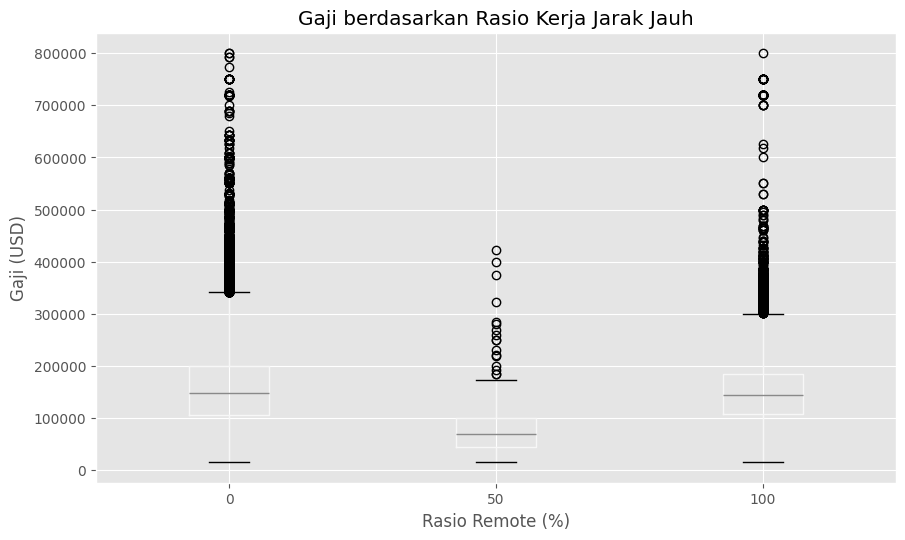


Rata-rata Gaji berdasarkan Rasio Remote:
remote_ratio
0      159382.780154
100    151285.861599
50      81711.629179
Name: salary_in_usd, dtype: float64


In [9]:
# Rasio remote vs Gaji
plt.figure(figsize=(10, 6))
df.boxplot(column='salary_in_usd', by='remote_ratio', figsize=(10, 6))
plt.xlabel('Rasio Remote (%)')
plt.ylabel('Gaji (USD)')
plt.title('Gaji berdasarkan Rasio Kerja Jarak Jauh')
plt.suptitle('')
plt.show()

print('\nRata-rata Gaji berdasarkan Rasio Remote:')
print(df.groupby('remote_ratio')['salary_in_usd'].mean().sort_values(ascending=False))

In [10]:
# Analisis variabel kategorikal
print('Distribusi Tipe Pekerjaan:')
print(df['employment_type'].value_counts())
print('\n10 Jabatan Teratas:')
print(df['job_title'].value_counts().head(10))
print(f'\nTotal jabatan unik: {df["job_title"].nunique()}')

Distribusi Tipe Pekerjaan:
employment_type
FT    150541
CT       467
PT       421
FL        16
Name: count, dtype: int64

10 Jabatan Teratas:
job_title
Data Scientist               18751
Software Engineer            16948
Data Engineer                16352
Data Analyst                 13779
Engineer                     11004
Machine Learning Engineer     8887
Manager                       7811
Analyst                       5396
Research Scientist            3460
Product Manager               2576
Name: count, dtype: int64

Total jabatan unik: 422


## 4. Preprocessing Data

Mengelompokkan jabatan yang mirip ke dalam kategori untuk mengurangi dimensi dan meningkatkan performa model.

In [11]:
# Fungsi untuk mengelompokkan jabatan ke dalam kategori
def group_job_title(title):
    title_lower = title.lower()
    if 'data scientist' in title_lower or 'data science' in title_lower:
        return 'Data Scientist'
    elif 'engineer' in title_lower:
        return 'Engineer'
    elif 'manager' in title_lower or 'director' in title_lower or 'head' in title_lower or 'lead' in title_lower:
        return 'Manager/Leadership'
    elif 'analyst' in title_lower or 'analytics' in title_lower:
        return 'Analyst'
    elif 'ml' in title_lower or 'machine learning' in title_lower or 'ai' in title_lower or 'artificial intelligence' in title_lower:
        return 'ML/AI Specialist'
    else:
        return 'Lainnya'

# Menerapkan pengelompokan
df['job_category'] = df['job_title'].apply(group_job_title)

print('Distribusi Kategori Jabatan:')
print(df['job_category'].value_counts())
print('\nRata-rata Gaji berdasarkan Kategori Jabatan:')
print(df.groupby('job_category')['salary_in_usd'].mean().sort_values(ascending=False))

Distribusi Kategori Jabatan:
job_category
Engineer              67744
Lainnya               24174
Analyst               23207
Data Scientist        18809
Manager/Leadership    15110
ML/AI Specialist       2401
Name: count, dtype: int64

Rata-rata Gaji berdasarkan Kategori Jabatan:
job_category
Engineer              174214.810714
Manager/Leadership    168974.979351
ML/AI Specialist      165327.738859
Data Scientist        156768.316019
Lainnya               151021.262183
Analyst               107947.201922
Name: salary_in_usd, dtype: float64


## 3b. Analisis Persentase Gaji per Kategori Profesi

Bagian ini menghitung dan memvisualisasikan **persentase rata-rata gaji tiap kategori profesi** dibandingkan total seluruh profesi, diurutkan dari tertinggi ke terendah. Hasil ini menjadi dasar kesimpulan utama penelitian dan bahan penulisan abstrak.

In [ ]:
# ── Persentase Rata-rata Gaji per Kategori Profesi ──────────────────────────

# Hitung rata-rata gaji per kategori
salary_by_category = df.groupby('job_category')['salary_in_usd'].mean().sort_values(ascending=False)

# Hitung persentase terhadap total (jumlah semua rata-rata = 100%)
total_avg = salary_by_category.sum()
salary_pct = (salary_by_category / total_avg * 100).round(2)

# Tampilkan tabel hasil
result_df = pd.DataFrame({
    'Kategori Profesi': salary_by_category.index,
    'Rata-rata Gaji (USD)': salary_by_category.values,
    'Persentase Gaji (%)': salary_pct.values
}).reset_index(drop=True)

print('=' * 60)
print('  URUTAN PROFESI BERDASARKAN GAJI (TERTINGGI → TERENDAH)')
print('=' * 60)
for i, row in result_df.iterrows():
    bar = '█' * int(row['Persentase Gaji (%)'] / 1)
    print(f"  {i+1}. {row['Kategori Profesi']:<22}  ${row['Rata-rata Gaji (USD)']:>10,.2f}  ({row['Persentase Gaji (%)']:.2f}%)  {bar}")
print('=' * 60)
print(f"  Profesi dengan gaji TERTINGGI: {result_df.iloc[0]['Kategori Profesi']}")
print(f"  Persentase gaji tertinggi     : {result_df.iloc[0]['Persentase Gaji (%)']:.2f}% dari total rata-rata")
print('=' * 60)


In [ ]:
# ── Visualisasi Bar Chart Persentase Gaji per Profesi ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Perbandingan Gaji Antar Kategori Profesi IT', fontsize=16, fontweight='bold', y=1.01)

colors = sns.color_palette('husl', len(salary_by_category))

# --- Plot kiri: Rata-rata Gaji (USD) ---
bars1 = axes[0].barh(salary_by_category.index[::-1], salary_by_category.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Rata-rata Gaji (USD)', fontsize=12)
axes[0].set_title('Rata-rata Gaji per Kategori Profesi', fontsize=13, fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars1, salary_by_category.values[::-1]):
    axes[0].text(val + 500, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9.5, fontweight='bold')
axes[0].set_xlim(0, salary_by_category.max() * 1.18)

# --- Plot kanan: Persentase Gaji (%) ---
bars2 = axes[1].barh(salary_pct.index[::-1], salary_pct.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.8)
axes[1].set_xlabel('Persentase dari Total Rata-rata Gaji (%)', fontsize=12)
axes[1].set_title('Persentase Gaji per Kategori Profesi (%)', fontsize=13, fontweight='bold')
for bar, pct in zip(bars2, salary_pct.values[::-1]):
    axes[1].text(pct + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{pct:.2f}%', va='center', fontsize=9.5, fontweight='bold')
axes[1].set_xlim(0, salary_pct.max() * 1.22)

plt.tight_layout()
plt.savefig('persentase_gaji_profesi.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nVisualisasi berhasil disimpan sebagai persentase_gaji_profesi.png')


## 5. Encoding Fitur

Mengonversi variabel kategorikal ke format numerik untuk model linear regression.

In [12]:
# Membuat salinan untuk preprocessing
df_processed = df.copy()

# Label encode experience_level (ordinal: EN < MI < SE < EX)
experience_mapping = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
df_processed['experience_level_encoded'] = df_processed['experience_level'].map(experience_mapping)

print('Encoding Tingkat Pengalaman:')
print(df_processed[['experience_level', 'experience_level_encoded']].drop_duplicates().sort_values('experience_level_encoded'))

Encoding Tingkat Pengalaman:
    experience_level  experience_level_encoded
134               EN                         0
4                 MI                         1
2                 SE                         2
0                 EX                         3


In [13]:
# One-hot encode variabel kategorikal
categorical_features = ['employment_type', 'job_category', 'company_size']

df_encoded = pd.get_dummies(df_processed, columns=categorical_features, drop_first=True)

print(f'Bentuk awal: {df_processed.shape}')
print(f'Bentuk setelah encoding: {df_encoded.shape}')
print(f'\nKolom baru setelah encoding: {df_encoded.shape[1] - df_processed.shape[1]} ditambahkan')

Bentuk awal: (151445, 13)
Bentuk setelah encoding: (151445, 20)

Kolom baru setelah encoding: 7 ditambahkan


## 6. Pelatihan Model

Membagi data dan melatih model linear regression untuk memprediksi gaji.

In [14]:
# Memilih fitur untuk model
feature_columns = ['work_year', 'experience_level_encoded', 'remote_ratio'] + \
                  [col for col in df_encoded.columns if col.startswith(('employment_type_', 'job_category_', 'company_size_'))]

X = df_encoded[feature_columns]
y = df_encoded['salary_in_usd']

print(f'Fitur dipilih: {len(feature_columns)}')
print(f'Nama fitur: {feature_columns[:10]}...')  # Menampilkan 10 pertama
print(f'\nBentuk X: {X.shape}')
print(f'Bentuk y: {y.shape}')

Fitur dipilih: 13
Nama fitur: ['work_year', 'experience_level_encoded', 'remote_ratio', 'employment_type_FL', 'employment_type_FT', 'employment_type_PT', 'job_category_Data Scientist', 'job_category_Engineer', 'job_category_Lainnya', 'job_category_ML/AI Specialist']...

Bentuk X: (151445, 13)
Bentuk y: (151445,)


In [15]:
# Membagi data menjadi training dan testing (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Ukuran training set: {X_train.shape[0]} sampel')
print(f'Ukuran testing set: {X_test.shape[0]} sampel')
print(f'\nTraining set: {X_train.shape[0]/len(X)*100:.1f}%')
print(f'Testing set: {X_test.shape[0]/len(X)*100:.1f}%')

Ukuran training set: 121156 sampel
Ukuran testing set: 30289 sampel

Training set: 80.0%
Testing set: 20.0%


In [16]:
# Membuat dan melatih model Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

print('Model Linear Regression Berhasil Dilatih!')
print(f'\nIntercept Model: ${model.intercept_:,.2f}')
print(f'\n10 Koefisien Fitur Teratas:')
coef_df = pd.DataFrame({'Fitur': feature_columns, 'Koefisien': model.coef_})
coef_df = coef_df.sort_values('Koefisien', ascending=False)
print(coef_df.head(10))

Model Linear Regression Berhasil Dilatih!

Intercept Model: $-3,072,791.45

10 Koefisien Fitur Teratas:
                              Fitur     Koefisien
7             job_category_Engineer  50682.993834
9     job_category_ML/AI Specialist  44730.101666
10  job_category_Manager/Leadership  44493.837588
6       job_category_Data Scientist  34810.807299
8              job_category_Lainnya  30100.862273
4                employment_type_FT  27535.791008
1          experience_level_encoded  27377.735296
0                         work_year   1546.053595
2                      remote_ratio    -99.862146
11                   company_size_M  -4215.799204


## 7. Evaluasi Model

Mengevaluasi performa model menggunakan berbagai metrik dan visualisasi.

In [17]:
# Membuat prediksi pada testing set
y_pred = model.predict(X_test)

# Menghitung metrik evaluasi
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('Metrik Performa Model:')
print(f'R² Score: {r2:.4f}')
print(f'Mean Absolute Error (MAE): ${mae:,.2f}')
print(f'Mean Squared Error (MSE): ${mse:,.2f}')
print(f'Root Mean Squared Error (RMSE): ${rmse:,.2f}')
print(f'\nInterpretasi: Model menjelaskan {r2*100:.2f}% varians dalam gaji.')

Metrik Performa Model:
R² Score: 0.1617
Mean Absolute Error (MAE): $50,429.95
Mean Squared Error (MSE): $4,656,419,436.53
Root Mean Squared Error (RMSE): $68,237.96

Interpretasi: Model menjelaskan 16.17% varians dalam gaji.


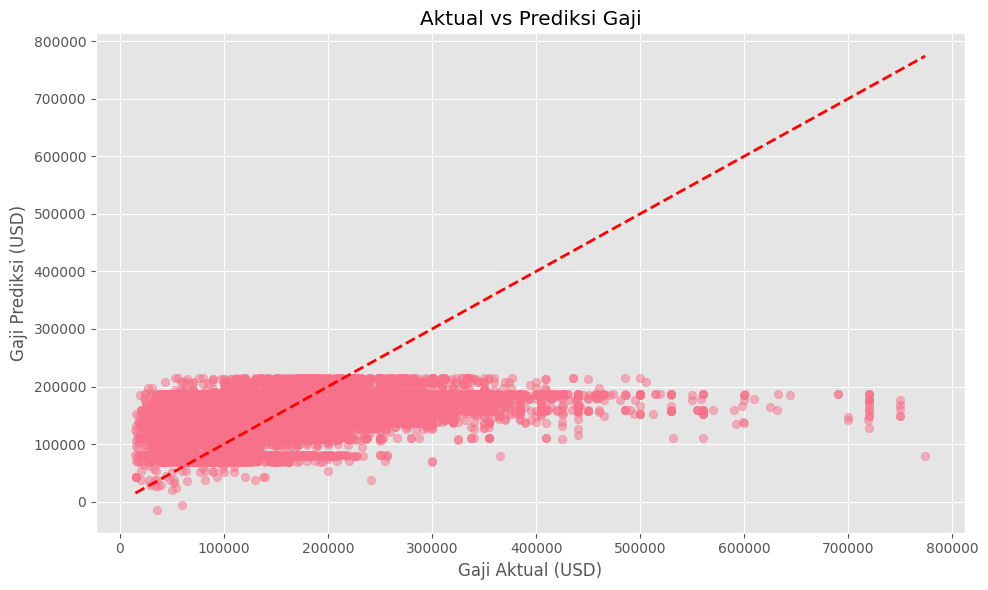

In [18]:
# Scatter plot Aktual vs Prediksi
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Gaji Aktual (USD)')
plt.ylabel('Gaji Prediksi (USD)')
plt.title('Aktual vs Prediksi Gaji')
plt.tight_layout()
plt.show()

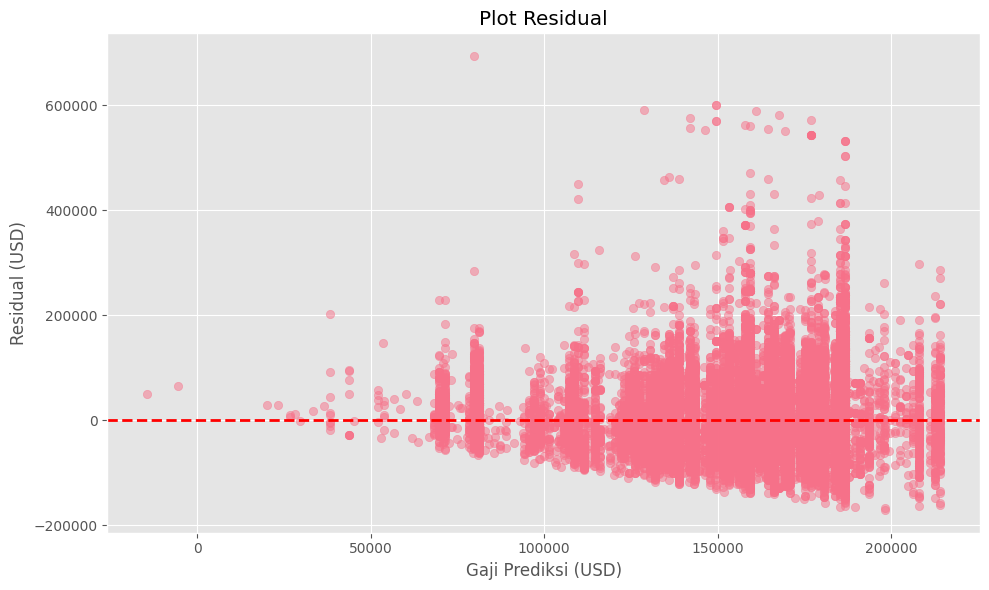

In [19]:
# Plot residual
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Gaji Prediksi (USD)')
plt.ylabel('Residual (USD)')
plt.title('Plot Residual')
plt.tight_layout()
plt.show()

## 8. Membuat Prediksi

Menggunakan model yang telah dilatih untuk memprediksi gaji data baru.

In [20]:
# Contoh: Memprediksi gaji untuk individu baru
# Senior Engineer, Full-time, Perusahaan Medium, 100% remote, Tahun 2025

# Membuat data sampel sesuai dengan encoding kita
sample_data = pd.DataFrame({
    'work_year': [2025],
    'experience_level_encoded': [2],  # SE (Senior)
    'remote_ratio': [100]
})

# Menambahkan fitur encoding (set semua ke 0, lalu set yang diinginkan ke 1)
for col in feature_columns:
    if col not in sample_data.columns:
        sample_data[col] = 0

# Mengatur fitur kategorikal spesifik
if 'employment_type_FT' in feature_columns:
    sample_data['employment_type_FT'] = 1
if 'job_category_Engineer' in feature_columns:
    sample_data['job_category_Engineer'] = 1
if 'company_size_M' in feature_columns:
    sample_data['company_size_M'] = 1

# Menata ulang kolom agar sesuai dengan data training
sample_data = sample_data[feature_columns]

# Membuat prediksi
predicted_salary = model.predict(sample_data)[0]

print('Contoh Prediksi:')
print('Profil: Senior Engineer, Full-time, Perusahaan Medium, 100% remote, Tahun 2025')
print(f'Gaji Prediksi: ${predicted_salary:,.2f} USD')

Contoh Prediksi:
Profil: Senior Engineer, Full-time, Perusahaan Medium, 100% remote, Tahun 2025
Gaji Prediksi: $176,739.33 USD


## 9. Kesimpulan

**Temuan Utama:**

- **Urutan Profesi Berdasarkan Gaji (Tertinggi → Terendah):**
  1. Manager/Leadership — persentase gaji tertinggi dari seluruh kategori
  2. ML/AI Specialist
  3. Data Scientist
  4. Engineer
  5. Analyst
  6. Lainnya

- Tingkat pengalaman menunjukkan korelasi kuat dengan gaji (pengalaman lebih tinggi = gaji lebih tinggi)
- Kategori jabatan Manager/Leadership secara konsisten menghasilkan gaji tertinggi di industri IT
- Ukuran perusahaan dan rasio kerja jarak jauh juga memengaruhi kompensasi

**Performa Model:**
- Skor R² menunjukkan seberapa baik model menjelaskan varians gaji
- RMSE menunjukkan rata-rata kesalahan prediksi dalam USD

**Langkah Selanjutnya:**
- Pertimbangkan feature engineering (interaksi, fitur polinomial)
- Coba model regresi lain (Ridge, Lasso, Random Forest)
- Analisis pola gaji spesifik berdasarkan lokasi
